In [2]:
# 작업디렉토리 변경
%cd "/content/drive/MyDrive/AI/26.06.10 자연어처리"

/content/drive/MyDrive/AI/26.06.10 자연어처리


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 텍스트마이닝
- 비정형 텍스트데이터에서 의미를 추출하거나 정형화된 데이터로 변경하는 작업
- 사람의 언어를 이해하는 관련기술을 자연어처리라고하며 기술적으로 겹치는 영역이 많다.

### 텍스트 마이닝 분석 프로세스

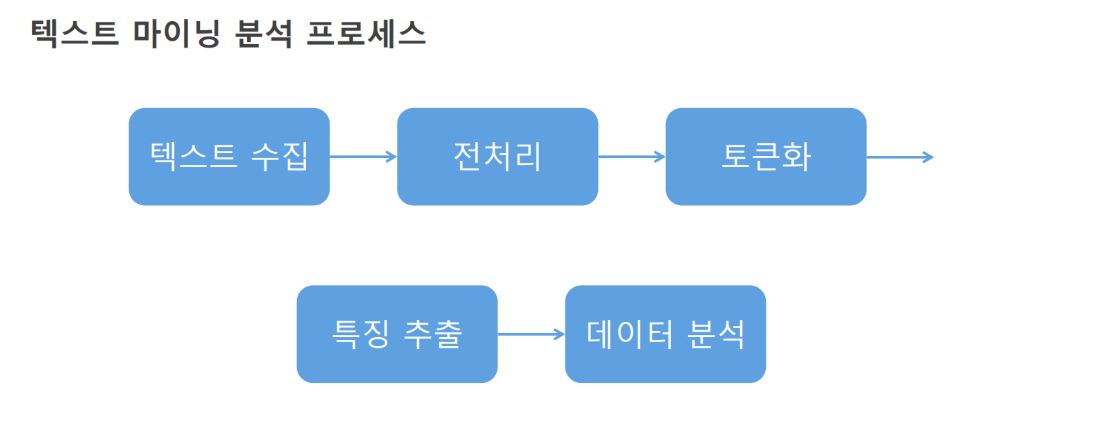

### 1\. 빈도분석
- 네이버쇼핑 리뷰데이터
- https://github.com/bab2min/corpus/tree/master/sentiment
- 네이버 쇼핑에 있는 댓글을 수집한 데이터로 구분자는 \t이다. 평점과 리뷰 두 개의 컬럼을 가지고 있다.

In [4]:
# pandas 이용해서 데이터를 읽고 전체 갯수를 확인해보자
# 주의사항 : 구분자를 \t로 설정해야 올바르게 읽어진다
import pandas as pd

In [5]:

naver_df = pd.read_csv("./data/naver_shopping.txt", sep='\t', # 구분자 변경
                       header=None) # 컬럼정보 없을을 명시
# 컬럼명 변경
naver_df.columns = ['평점', '리뷰']
naver_df.head()

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [6]:
# 데이터 갯수 확인
naver_df.shape

(200000, 2)

#### 말뭉치와 문서
- 말뭉치 (corpus) : 텍스트마이닝, 자연어처리에서 사용되는 데이터셋 덩어리
- 문서 (document) : 말뭉치는 구성하는 개별 text 요소

#### 토큰화
- 토큰화 (Tokenize) : 일정단위로 문장을 쪼개는 작업
    1. 글자(char)
    2. 단어(띄어쓰기)
    3. 형태소
    4. N-gram

In [7]:
# 모든 문서를 토큰화하자
tokens = [] # 20만개의 리뷰의 모든 토큰을 담을 리스트
for doc in naver_df['리뷰'] : # 리뷰열을 꺼내서 반복
    for token in doc.split(" ") : # 띄어쓰기 중심으로 각 리뷰들을 토큰화
        tokens.append(token) # 잘라낸 개별토큰을 리스트에

In [8]:
tokens

['배공빠르고',
 '굿',
 '택배가',
 '엉망이네용',
 '저희집',
 '밑에층에',
 '말도없이',
 '놔두고가고',
 '아주좋아요',
 '바지',
 '정말',
 '좋아서2개',
 '더',
 '구매했어요',
 '이가격에',
 '대박입니다.',
 '바느질이',
 '조금',
 '엉성하긴',
 '하지만',
 '편하고',
 '가성비',
 '최고예요.',
 '선물용으로',
 '빨리',
 '받아서',
 '전달했어야',
 '하는',
 '상품이었는데',
 '머그컵만',
 '와서',
 '당황했습니다.',
 '전화했더니',
 '바로주신다했지만',
 '배송도',
 '누락되어있었네요..',
 '확인안하고',
 '바로',
 '선물했으면',
 '큰일날뻔했네요..이렇게',
 '배송이',
 '오래걸렸으면',
 '사는거',
 '다시',
 '생각했을거같아요',
 '아쉽네요..',
 '민트색상',
 '예뻐요.',
 '옆',
 '손잡이는',
 '거는',
 '용도로도',
 '사용되네요',
 'ㅎㅎ',
 '비추합니다',
 '계란',
 '뒤집을',
 '때',
 '완전',
 '불편해요',
 'ㅠㅠ',
 '코팅도',
 '묻어나고',
 '보기엔',
 '예쁘고',
 '실용적으로',
 '보였는데',
 '생각보다',
 '진짜',
 '별로입니다.',
 '주문을',
 '11월6에',
 '시켰는데',
 '11월16일에',
 '배송이',
 '왔네요',
 'ㅎㅎㅎ',
 '여기',
 '회사측과는',
 '전화도',
 '안되고',
 '아무런',
 '연락을',
 '받을수가',
 '없으니',
 '답답하신',
 '분들은',
 '다른곳에서',
 '사시는거',
 '추천드립니다',
 '넉넉한',
 '길이로',
 '주문했는데도',
 '안',
 '맞네요',
 '별로예요',
 '보폴이',
 '계속',
 '때처럼',
 '나오다가',
 '지금은',
 '안나네요~',
 '110인데',
 '전문속옷브랜드',
 '위생팬티105보다',
 '작은듯해요.',
 '불편해요.',
 '밴딩부분이',
 '다',
 '신축성없는',
 '일반실로',
 '되어있

#### 특징추출(수치화)
- 의미있는 숫자를 뽑아내는 작업
- 우리는 빈도를 기반으로 숫자를 뽑아보자

In [9]:
from collections import Counter

In [10]:
# 도구생성
counter = Counter(tokens) # 토큰화된 데이터를 넣어서 생성

In [11]:
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

[('너무', 22004),
 ('잘', 17893),
 ('재구매', 13791),
 ('좋아요', 11082),
 ('그냥', 9681),
 ('좀', 8214),
 ('다', 7085),
 ('많이', 6585),
 ('더', 6520),
 ('생각보다', 6119),
 ('배송도', 5278),
 ('배송', 4731),
 ('정말', 4581),
 ('빠르고', 3818),
 ('배송이', 3661),
 ('아주', 3636),
 ('ㅠㅠ', 3627),
 ('진짜', 3589),
 ('또', 3355),
 ('샀는데', 3352)]

#### 실습
- 배송과 관련된 리뷰들에서 자주 등장하는 상위 20개 단어를 확인해보자
- 진행순서
    1. 배송단어가 들어간 리뷰 필터링
    2. 토큰화 실시
    3. 카운터로 빈도 측정 및 확인
- 필터링관련 함수 :
    https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html#pandas.Series.str.contains

In [12]:
# 1. 배송 단어가 들어간 리뷰만 필터링
delivery_df = naver_df[naver_df['리뷰'].str.contains('배송', na=False)]

# 2. 필터링된 리뷰를 하나씩 꺼내기
# 3. 각 리뷰를 split()으로 토큰화
# 4. 토큰들을 하나의 리스트에 모으기
delivery_tokens = []

for doc in delivery_df['리뷰']:
    for token in doc.split():
        delivery_tokens.append(token)

# 5. Counter로 단어 빈도 계산
from collections import Counter

delivery_counter = Counter(delivery_tokens)

# 6. most_common(20)으로 상위 20개 단어 확인
delivery_counter.most_common(20)

[('배송도', 5278),
 ('배송', 4731),
 ('배송이', 3661),
 ('빠르고', 3556),
 ('너무', 2950),
 ('잘', 2446),
 ('재구매', 2118),
 ('배송은', 1961),
 ('좋아요', 1708),
 ('그냥', 1223),
 ('좀', 1070),
 ('다', 1005),
 ('빠른', 963),
 ('배송빠르고', 928),
 ('빠른배송', 868),
 ('많이', 815),
 ('더', 806),
 ('정말', 787),
 ('생각보다', 665),
 ('엄청', 603)]

In [13]:
# 리뷰에 배송이 포함된 글자 필터링
배송_df = naver_df[naver_df['리뷰'].str.contains('배송', na=False)]
배송_df.shape

(26871, 2)

In [14]:
# 리스트 컴프리헨션 문법 활용
tokens = [ token for doc in 배송_df['리뷰'] for token in doc.split(" ")]

In [15]:
# 위의 코드와 같은 기능을 수행
# for doc in 배송_df['리뷰']:
#      for token in doc.split(" "):
#         tokens.append(token)

In [16]:
tokens

['선물용으로',
 '빨리',
 '받아서',
 '전달했어야',
 '하는',
 '상품이었는데',
 '머그컵만',
 '와서',
 '당황했습니다.',
 '전화했더니',
 '바로주신다했지만',
 '배송도',
 '누락되어있었네요..',
 '확인안하고',
 '바로',
 '선물했으면',
 '큰일날뻔했네요..이렇게',
 '배송이',
 '오래걸렸으면',
 '사는거',
 '다시',
 '생각했을거같아요',
 '아쉽네요..',
 '주문을',
 '11월6에',
 '시켰는데',
 '11월16일에',
 '배송이',
 '왔네요',
 'ㅎㅎㅎ',
 '여기',
 '회사측과는',
 '전화도',
 '안되고',
 '아무런',
 '연락을',
 '받을수가',
 '없으니',
 '답답하신',
 '분들은',
 '다른곳에서',
 '사시는거',
 '추천드립니다',
 '재구매',
 '늘',
 '사는',
 '흙이에요',
 '팽이들이',
 '젤',
 '좋아해요',
 '빠른배송',
 '감사합니다',
 '배송기사나,',
 '판매하는',
 '회사나',
 '불친절하고',
 '불쾌합니다.',
 '서비스면에선',
 '최악이네요',
 '제품은',
 '그럭저럭',
 '쓸만합니다.',
 '싼게',
 '비지떡',
 '마인드부터',
 '갖추고',
 '장사하시길바랍니다.',
 '이익에',
 '눈',
 '진짜',
 '너무하시네요',
 '배송이늦는건',
 '엄절수없다하고',
 '참앗지만',
 '밑에',
 '서랍이',
 '금방',
 '안되서',
 'AS되냐고',
 '물어봣는데',
 '전화도',
 '안받고',
 '10시에',
 '톡을보냇는데',
 '오후6시에',
 '답해서',
 '뭐하나물어보려고하니',
 '상담시간이아니라고',
 '뜨네요',
 '빨리as좀',
 '해주세요',
 '안되면',
 '안된다고',
 '답장부탁드립니다',
 '빠른',
 '배송과',
 '친절한',
 '설명',
 '빠른',
 '배송',
 '짱짱',
 '항상',
 '애용해서',
 'ㅋㅋㅋ리뷰남기기도뭐하네요ㅋㅋ이것만',
 '먹어요',
 '배송도',
 '빨라요',
 '5센치',


In [41]:
# 도구생성
counter = Counter(tokens) # 토큰화된 데이터를 넣어서 생성
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

[('배송', 28502),
 ('제품', 2922),
 ('포장', 2247),
 ('구매', 2221),
 ('주문', 2164),
 ('가격', 2018),
 ('상품', 1932),
 ('사용', 1454),
 ('그냥', 1427),
 ('좀', 1401),
 ('생각', 1245),
 ('더', 1056),
 ('상태', 981),
 ('개', 944),
 ('정말', 937),
 ('물건', 936),
 ('맛', 925),
 ('배송비', 906),
 ('것', 903),
 ('때', 864)]

### 2\. 정규표현식(Regular Expression)
- 특정한 규칙을 가진 문자열의 집할을 표현하는 언어
- 핸드폰번호, 이메일처럼 패턴이 있는 문자열을 검색, 치환하는 도구
- 대부분의 프로그래밍 언어에서 지원
- https://wikidocs.net/21703

In [18]:
# 정규표현식을 지원하는 패키지 임포트

import re

In [19]:
# 핸드폰 번호 검출
# 패턴 만들기
p = re.compile("010-?[0-9]{4}-?\\d{4}")

In [20]:
p.search("안녕하세요 제 핸드폰 번호는 010-1234-5678입니다.")

<re.Match object; span=(16, 29), match='010-1234-5678'>

In [21]:
p.search("안녕하세요 제 핸드폰 번호는 01012345678입니다.")

<re.Match object; span=(16, 27), match='01012345678'>

In [22]:
p.search("안녕하세요 제 핸드폰 번호는 0101234567입니다.")

#### 배송이 포함된 데이터 클렌징하기
- 숫자
- 알파벳(대소문자)
- 문장보후(!?~등)
- 반복적인 글자(ㅋ, ㅎ, ㅠ, ㅇ 등)
- 실습순서
    1. 패턴만들기
    2. 문장 토큰화
    3. search 이용해서 패턴에 검출된 토큰은 제외하고 전체 리스트에 추가

In [23]:
배송_df.head()

,평점,리뷰
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
6,1,주문을 11월6에 시켰는데 11월16일에 배송이 왔네요 ㅎㅎㅎ 여기 회사측과는 전화...
24,5,재구매 늘 사는 흙이에요 팽이들이 젤 좋아해요 빠른배송 감사합니다
26,2,"배송기사나, 판매하는 회사나 불친절하고 불쾌합니다. 서비스면에선 최악이네요 제품은 ..."
41,1,진짜 너무하시네요 배송이늦는건 엄절수없다하고 참앗지만 밑에 서랍이 금방 안되서 AS...


In [24]:
#패턴생성
p = re.compile("[0-9a-zA-Z?!@~.ㅋㅎㅠㅜㅇ]+")

In [25]:
clean_review = [] # 전처리가 끝난 데이터를 담을 리스트
for doc in 배송_df['리뷰'] : # 배송과 관련된 리뷰를 반복
  temp = [] # doc단위로 묶기 위한 임시 리스트
  for token in doc.split(" ") : # 하나의 리뷰를 띄어쓰기 중심으로 토큰화
    if not p.search(token) : # 패턴과 일치여부를 검사
      temp.append(token) # doc단위 리스트에 클린토큰 추가
  clean_review.append(temp) # 전체리스트에 doc단위로 추가

In [26]:
clean_review

[['선물용으로',
  '빨리',
  '받아서',
  '전달했어야',
  '하는',
  '상품이었는데',
  '머그컵만',
  '와서',
  '전화했더니',
  '바로주신다했지만',
  '배송도',
  '확인안하고',
  '바로',
  '선물했으면',
  '배송이',
  '오래걸렸으면',
  '사는거',
  '다시',
  '생각했을거같아요'],
 ['주문을',
  '시켰는데',
  '배송이',
  '왔네요',
  '여기',
  '회사측과는',
  '전화도',
  '안되고',
  '아무런',
  '연락을',
  '받을수가',
  '없으니',
  '답답하신',
  '분들은',
  '다른곳에서',
  '사시는거',
  '추천드립니다'],
 ['재구매', '늘', '사는', '흙이에요', '팽이들이', '젤', '좋아해요', '빠른배송', '감사합니다'],
 ['배송기사나,',
  '판매하는',
  '회사나',
  '불친절하고',
  '서비스면에선',
  '최악이네요',
  '제품은',
  '그럭저럭',
  '싼게',
  '비지떡',
  '마인드부터',
  '갖추고',
  '이익에',
  '눈'],
 ['진짜',
  '너무하시네요',
  '배송이늦는건',
  '엄절수없다하고',
  '참앗지만',
  '밑에',
  '서랍이',
  '금방',
  '안되서',
  '물어봣는데',
  '전화도',
  '안받고',
  '톡을보냇는데',
  '답해서',
  '뭐하나물어보려고하니',
  '상담시간이아니라고',
  '뜨네요',
  '해주세요',
  '안되면',
  '안된다고',
  '답장부탁드립니다'],
 ['빠른', '배송과', '친절한', '설명'],
 ['빠른', '배송', '짱짱'],
 ['항상', '애용해서', '먹어요', '배송도', '빨라요'],
 ['토퍼', '사용하는데', '사이즈', '잘', '맞고', '배송은', '좀', '늦게'],
 ['빠른',
  '배송은',
  '마음에',
  '드는데',
  '사진과',
  '다른',
  '증정품을',
  '변경',
  

In [27]:
# 1. 패턴 만들기
pattern = r'[0-9]|[a-zA-Z]|[^\w\s가-힣]|[ㅋㅎㅠㅜㅇ]+'

# 전체 토큰을 담을 리스트
배송_tokens = []

# 2. 문장 토큰화
for doc in 배송_df['리뷰']:
    for token in str(doc).split():

        # 3. search 이용해서 패턴에 검출된 토큰은 제외하고 전체 리스트에 추가
        if not re.search(pattern, token):
            배송_tokens.append(token)

# 전체 토큰 확인
배송_tokens

['선물용으로',
 '빨리',
 '받아서',
 '전달했어야',
 '하는',
 '상품이었는데',
 '머그컵만',
 '와서',
 '전화했더니',
 '바로주신다했지만',
 '배송도',
 '확인안하고',
 '바로',
 '선물했으면',
 '배송이',
 '오래걸렸으면',
 '사는거',
 '다시',
 '생각했을거같아요',
 '주문을',
 '시켰는데',
 '배송이',
 '왔네요',
 '여기',
 '회사측과는',
 '전화도',
 '안되고',
 '아무런',
 '연락을',
 '받을수가',
 '없으니',
 '답답하신',
 '분들은',
 '다른곳에서',
 '사시는거',
 '추천드립니다',
 '재구매',
 '늘',
 '사는',
 '흙이에요',
 '팽이들이',
 '젤',
 '좋아해요',
 '빠른배송',
 '감사합니다',
 '판매하는',
 '회사나',
 '불친절하고',
 '서비스면에선',
 '최악이네요',
 '제품은',
 '그럭저럭',
 '싼게',
 '비지떡',
 '마인드부터',
 '갖추고',
 '이익에',
 '눈',
 '진짜',
 '너무하시네요',
 '배송이늦는건',
 '엄절수없다하고',
 '참앗지만',
 '밑에',
 '서랍이',
 '금방',
 '안되서',
 '물어봣는데',
 '전화도',
 '안받고',
 '톡을보냇는데',
 '답해서',
 '뭐하나물어보려고하니',
 '상담시간이아니라고',
 '뜨네요',
 '해주세요',
 '안되면',
 '안된다고',
 '답장부탁드립니다',
 '빠른',
 '배송과',
 '친절한',
 '설명',
 '빠른',
 '배송',
 '짱짱',
 '항상',
 '애용해서',
 '먹어요',
 '배송도',
 '빨라요',
 '토퍼',
 '사용하는데',
 '사이즈',
 '잘',
 '맞고',
 '배송은',
 '좀',
 '늦게',
 '빠른',
 '배송은',
 '마음에',
 '드는데',
 '사진과',
 '다른',
 '증정품을',
 '변경',
 '되었으면',
 '미리',
 '고지해주셨으면',
 '재구매',
 '회사에서',
 '쓰는거라',
 '자주',
 '좀',
 '빨리',
 '떨어지는거'

In [28]:
# 4. Counter로 단어 빈도 계산
from collections import Counter

배송_counter = Counter(배송_tokens)

# 5. most_common(20)으로 상위 20개 단어와 빈도 확인
배송_counter.most_common(20)

[('배송도', 5278),
 ('배송', 4731),
 ('배송이', 3661),
 ('빠르고', 3556),
 ('너무', 2950),
 ('잘', 2446),
 ('재구매', 2118),
 ('배송은', 1961),
 ('좋아요', 1708),
 ('그냥', 1223),
 ('좀', 1070),
 ('다', 1005),
 ('빠른', 963),
 ('배송빠르고', 928),
 ('빠른배송', 868),
 ('많이', 815),
 ('더', 806),
 ('정말', 787),
 ('생각보다', 665),
 ('엄청', 603)]

### 3. 형태소 분석
- 형태소 의미를 가진 가장 작은 단위
- Konlpy : https://konlpy.org/ko/latest/index.html
- Kiwi : https://github.com/bab2min/kiwipiepy

### mecab 설치하기

In [29]:
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

In [30]:
# !bash ./Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

In [31]:
from konlpy.tag import Mecab, Okt, Kkma

In [32]:
okt = Okt() #트위터 기반으로 시작된 형태소 분석기, 비교적 신조어 분리에 강함
mecab = Mecab() # 리눅스기반의 환경에서 동작, 속도가 빠르다
kkma = Kkma() # Java기반의 분석기, 속도는 느리지만 품사분리가 정교하다

In [33]:

#형태소분리
mecab.morphs("아버지 가방에 들어가신다")

['아버지', '가', '방', '에', '들어가', '신다']

In [34]:
# 품사확인하기
print(okt.tagset)
print(kkma.tagset)

{'Adjective': '형용사', 'Adverb': '부사', 'Alpha': '알파벳', 'Conjunction': '접속사', 'Determiner': '관형사', 'Eomi': '어미', 'Exclamation': '감탄사', 'Foreign': '외국어, 한자 및 기타기호', 'Hashtag': '트위터 해쉬태그', 'Josa': '조사', 'KoreanParticle': '(ex: ㅋㅋ)', 'Noun': '명사', 'Number': '숫자', 'PreEomi': '선어말어미', 'Punctuation': '구두점', 'ScreenName': '트위터 아이디', 'Suffix': '접미사', 'Unknown': '미등록어', 'Verb': '동사'}
{'EC': '연결 어미', 'ECD': '의존적 연결 어미', 'ECE': '대등 연결 어미', 'ECS': '보조적 연결 어미', 'EF': '종결 어미', 'EFA': '청유형 종결 어미', 'EFI': '감탄형 종결 어미', 'EFN': '평서형 종결 어미', 'EFO': '명령형 종결 어미', 'EFQ': '의문형 종결 어미', 'EFR': '존칭형 종결 어미', 'EP': '선어말 어미', 'EPH': '존칭 선어말 어미', 'EPP': '공손 선어말 어미', 'EPT': '시제 선어말 어미', 'ET': '전성 어미', 'ETD': '관형형 전성 어미', 'ETN': '명사형 전성 어미', 'IC': '감탄사', 'JC': '접속 조사', 'JK': '조사', 'JKC': '보격 조사', 'JKG': '관형격 조사', 'JKI': '호격 조사', 'JKM': '부사격 조사', 'JKO': '목적격 조사', 'JKQ': '인용격 조사', 'JKS': '주격 조사', 'JX': '보조사', 'MA': '부사', 'MAC': '접속 부사', 'MAG': '일반 부사', 'MD': '관형사', 'MDN': '수 관형사', 'MDT': '일반 관형사', 'NN': '명사', 'NNB': '일반 의존

In [35]:
# pos tagging
result = kkma.pos(" ".join(clean_review[0]))

In [36]:
# 반복문으로 명사 추출하기
for t in result :
  if t[1] == 'NNG' :
    print(t[0], t[1])

선물 NNG
상품 NNG
컵 NNG
전화 NNG
주신 NNG
배송 NNG
확인 NNG
안 NNG
선물 NNG
배송 NNG
생각 NNG


### 실습 : 배송관련 리뷰에서 명사만 추출하여 빈도분석하기

In [40]:
noun_tokens = [] # 명사만 들어갈 전체리스트
for doc in 배송_df['리뷰'] :
  # 형태소분석기를 이용해 품사 확인하기
  morphs = okt.pos(doc) # 형태소 분리
  for t in morphs : # 형태소별로 반복처리
    if t[1] == "Noun" : # 일반명사만 필터링
      noun_tokens.append(t[0]) # 형태소 토큰 추가

In [42]:
# 도구생성
counter = Counter(noun_tokens) # 토큰화된 데이터를 넣어서 생성
# 빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

[('배송', 28502),
 ('제품', 2922),
 ('포장', 2247),
 ('구매', 2221),
 ('주문', 2164),
 ('가격', 2018),
 ('상품', 1932),
 ('사용', 1454),
 ('그냥', 1427),
 ('좀', 1401),
 ('생각', 1245),
 ('더', 1056),
 ('상태', 981),
 ('개', 944),
 ('정말', 937),
 ('물건', 936),
 ('맛', 925),
 ('배송비', 906),
 ('것', 903),
 ('때', 864)]

### kiwi사용하기
- https://github.com/bab2min/kiwi
- https://github.com/bab2min/kiwipiepy

In [50]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 13.9 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=750f1f90aff8ec0796ae7d2a91116377759d4aec71bf74ea9f5b2da5428e7150
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [53]:
from kiwipiepy import Kiwi

In [54]:
# 도구생성
kiwi = Kiwi()

In [55]:
# 형태소단위로 분리
rs = kiwi.tokenize("아버지가 방에 들어가신다")

In [56]:
rs

[Token(form='아버지', tag='NNG', start=0, len=3),
 Token(form='가', tag='JKS', start=3, len=1),
 Token(form='방', tag='NNG', start=5, len=1),
 Token(form='에', tag='JKB', start=6, len=1),
 Token(form='들어가', tag='VV', start=8, len=3),
 Token(form='시', tag='EP', start=11, len=1),
 Token(form='ᆫ다', tag='EF', start=11, len=2)]

In [59]:
# 토큰에 접근하기
rs[0]

Token(form='아버지', tag='NNG', start=0, len=3)

In [61]:
# 데이터 꺼내기
print(rs[0].form)
print(rs[0].tag)

아버지
NNG


In [62]:
# 띄어쓰기 교정
kiwi.space("아버지가방에들어가신다.")

'아버지가 방에 들어가신다.'

### 4. 불용어(Stop word)처리
- 분석에 사용되지 않는 단어를 제거하는 기법

In [47]:
#불용어 리스트
stop_words = ["배송", "좀", "개", "더", "것," "때"]

In [48]:
noun_tokens_remove_stop = [] # 불용어처리된 토큰이 담길 리스트

for token in noun_tokens : # 전체토큰 반복
  if token not in stop_words : # 불용어가 아니라면
    noun_tokens_remove_stop.append(token) # 추가

In [49]:
#도구생성
counter = Counter(noun_tokens_remove_stop) # 토큰화된 데이터를 넣어서 생성
#빈도확인
counter.most_common(20) # 빈도가 높은 상위 20개 데이터 확인

[('제품', 2922),
 ('포장', 2247),
 ('구매', 2221),
 ('주문', 2164),
 ('가격', 2018),
 ('상품', 1932),
 ('사용', 1454),
 ('그냥', 1427),
 ('생각', 1245),
 ('상태', 981),
 ('정말', 937),
 ('물건', 936),
 ('맛', 925),
 ('배송비', 906),
 ('것', 903),
 ('때', 864),
 ('맘', 763),
 ('택배', 743),
 ('빨', 734),
 ('요', 725)]

### 5.이모지 처리


In [63]:
# 패키지 설치
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.3 MB/s eta 0:00:00


In [64]:
import emoji

In [67]:
# 이모지 제거
emoji.replace_emoji("이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다.😊💕")

'이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다.'

In [66]:
# 이모지 글자를 살리는 경우
emoji.demojize("이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다.😘😁")

'이 쇼핑몰 너무 좋아요. 빠른 배송 감사합니다.:face_blowing_a_kiss::beaming_face_with_smiling_eyes:'

### 6. N-gram
- 연속적인 단어의 의미 보존을 위해 처리하는 방법
- 1-gram(유니그램) : 한 단어(글자)를 토큰으로 등록
- 2-gram(바이그램) : 두 단어(글자)를 토큰으로 등록
- 3-gram(트라이그램) : 세 단어(글자)를 토큰으로 등록
- 너무 과도하고 n-gram을 쓸 경우 토큰화의 의미가 감소

In [72]:
from nltk.util import ngrams

In [77]:
# 토큰화된 예시데이터 준비
sample_tokens = ['오늘', '저녁에', '무엇을', '먹을까', '?']

In [78]:
# 바이그램
bi_result = list(ngrams(sample_tokens,2))

In [79]:
bi_result

[('오늘', '저녁에'), ('저녁에', '무엇을'), ('무엇을', '먹을까'), ('먹을까', '?')]

In [80]:
# 트라이그램
tri_result = list(ngrams(sample_tokens,3))

In [81]:
tri_result

[('오늘', '저녁에', '무엇을'), ('저녁에', '무엇을', '먹을까'), ('무엇을', '먹을까', '?')]

### N-gram을 적용해서 빈도분석 해보기
- kiwi 활용
- 유니,바이,트라이 적용 후 빈도 측정

In [85]:
n_gram_clean_reviews = [] # n-gram이 적용된 데이터가 담길 리스트
clean_reviews = [] # NNG, VV, VA로 클렌징된 리스트

for doc in 배송_df['리뷰'] : # 배송리뷰 반복처리
  morphs = kiwi.tokenize(doc) # 형태소분석
  morphs_tokens = [] # 일반명사, 동사, 형용사만 필터링하는 리스트
  for t in morphs : # 토큰 반복처리
    if t.tag in ['NNG', "VV", 'VA'] : # 조건처리
      morphs_tokens.append(t.form) # 토큰추가

    clean_reviews.append(morphs_tokens) # 전체리스트에 추가

In [89]:
clean_reviews

[['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  '생각',
  '같'],
 ['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  '생각',
  '같'],
 ['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  '생각',
  '같'],
 ['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  '생각',
  '같'],
 ['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  '생각',
  '같'],
 ['선물',
  '전달',
  '상품',
  '머그',
  '컵',
  '오',
  '당황',
  '전화',
  '주',
  '하',
  '배송',
  '누락',
  '확인',
  '하',
  '선물',
  '큰일',
  '나',
  '배송',
  '걸리',
  '사',
  

In [93]:
 n_gram_clean_reviews = [] # n-gram이 적용된 리뷰를 담을 리스트

for doc in clean_reviews : # 클렌징된 전체데이터를 반복
  temp_tokens = [] # 하나의 리뷰에 대한 중간결과 리스트 <- (유니그램 토큰, 바이그램 토큰)
  bi_tokens = list(ngrams(doc,2)) # 바이그램 생성
  tri_tokens = list(ngrams(doc,3)) # 트라이그램 생성
  # 유니그램 데이터 추가
  temp_tokens = temp_tokens + doc
  # 바이그램 데이터 추가
  for t in bi_tokens :
    temp_tokens.append(" ".join(t)) # 두 단어를 하나의 문자열로 결합하여 추가
  # 트라이그램 데이터 추가
  for t in tri_tokens :
    temp_tokens.append(" ".join(t)) # 두 단어를 하나의 문자열로 결합하여 추가
  n_gram_clean_reviews.append(temp_tokens) # 전체리스트에 추가

In [94]:
 # 빈도분석
# 하나의 리스트에 모든 토큰 담기
배송_n_gram_tokens = [ t  for doc in n_gram_clean_reviews for t in doc]

# 빈도측정
counter = Counter(배송_n_gram_tokens)
counter.most_common(50)

[('배송', 788682),
 ('빠르', 312602),
 ('좋', 305172),
 ('하', 245344),
 ('배송 빠르', 239447),
 ('오', 184485),
 ('구매', 160150),
 ('쓰', 141038),
 ('같', 116388),
 ('되', 112208),
 ('주문', 104895),
 ('제품', 103096),
 ('있', 97574),
 ('사', 94112),
 ('없', 87881),
 ('포장', 75805),
 ('만족', 73562),
 ('먹', 73203),
 ('상품', 67196),
 ('가격', 63640),
 ('빠르 배송', 62726),
 ('걸리', 57240),
 ('사용', 56964),
 ('보내', 56948),
 ('감사', 54509),
 ('느리', 52116),
 ('늦', 50679),
 ('들', 48756),
 ('나', 46221),
 ('생각', 45390),
 ('때', 45111),
 ('배송 느리', 43655),
 ('빠르 좋', 42385),
 ('배송 빠르 좋', 41068),
 ('배송 오', 39407),
 ('가', 36835),
 ('배송비', 35455),
 ('보', 35422),
 ('좋 배송', 35379),
 ('주', 35239),
 ('상태', 35189),
 ('물건', 34074),
 ('박스', 32788),
 ('택배', 32484),
 ('괜찮', 31180),
 ('맛', 30647),
 ('시키', 30429),
 ('사이즈', 29768),
 ('배송 늦', 29315),
 ('알', 28767)]